## Data Description And Analysis 

In [2]:
import numpy as np 
import pandas as pd 

import gc
import os 

import matplotlib
import matplotlib.pyplot as plt 
import seaborn as sns 

color = sns.color_palette()

root = 'C:/Users/abhay/Minor_Project/Dataset'

The dataset contains relational set of files describing customers' orders over time. For each user, 4 to 100 orders are provided with the sequence of products purchased in each order.

In [3]:
os.listdir(root)

['aisles.csv',
 'departments.csv',
 'orders.csv',
 'order_products__prior.csv',
 'order_products__train.csv',
 'products.csv']

In [4]:
aisles = pd.read_csv(root+ '/aisles.csv')
departments = pd.read_csv(root+ '/departments.csv')
orders = pd.read_csv(root + '/orders.csv')
order_products_prior = pd.read_csv(root + '/order_products__prior.csv')
order_products_train = pd.read_csv(root + '/order_products__train.csv')
products = pd.read_csv(root + '/products.csv')

### Aisles:
This file contains different aisles and there are total 134 unique aisles.

In [5]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [6]:
aisles.tail()

,aisle_id,aisle
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief
133,134,specialty wines champagnes


In [7]:
len(aisles.aisle.unique())

134

In [8]:
aisles.aisle.unique()

array(['prepared soups salads', 'specialty cheeses',
       'energy granola bars', 'instant foods',
       'marinades meat preparation', 'other', 'packaged meat',
       'bakery desserts', 'pasta sauce', 'kitchen supplies',
       'cold flu allergy', 'fresh pasta', 'prepared meals',
       'tofu meat alternatives', 'packaged seafood', 'fresh herbs',
       'baking ingredients', 'bulk dried fruits vegetables',
       'oils vinegars', 'oral hygiene', 'packaged cheese', 'hair care',
       'popcorn jerky', 'fresh fruits', 'soap', 'coffee', 'beers coolers',
       'red wines', 'honeys syrups nectars', 'latino foods',
       'refrigerated', 'packaged produce', 'kosher foods',
       'frozen meat seafood', 'poultry counter', 'butter',
       'ice cream ice', 'frozen meals', 'seafood counter',
       'dog food care', 'cat food care', 'frozen vegan vegetarian',
       'buns rolls', 'eye ear care', 'candy chocolate', 'mint gum',
       'vitamins supplements', 'breakfast bars pastries',
       '

### Departments:
This file contains different departments and there are total 21 unique departments.

In [9]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [10]:
departments.tail()

,department_id,department
16,17,household
17,18,babies
18,19,snacks
19,20,deli
20,21,missing


In [11]:
len(departments.department.unique())

21

In [12]:
departments.department.unique()

array(['frozen', 'other', 'bakery', 'produce', 'alcohol', 'international',
       'beverages', 'pets', 'dry goods pasta', 'bulk', 'personal care',
       'meat seafood', 'pantry', 'breakfast', 'canned goods',
       'dairy eggs', 'household', 'babies', 'snacks', 'deli', 'missing'],
      dtype=object)

## Orders:
This file contains all the orders made by different users. From below analysis, we can conclude following:

- There are total 3421083 orders made by total 206209 users.
- There are three sets of orders: Prior, Train, test. The distribution of orders in Train and Test sets similar whereas the distribution of orders in Prior set is different.
- The total orders per customer ranges from 0 to 100.
- Based on the plot of 'Orders VS Day of Week' we can map 0 and 1 as sunday and monday respectively.
- Majority of the orders are made during the day time(9 am to 7 pm).
- Most Customers orders once in a week which is supported by peaks at 7,14,21, and 30 in 'Order Vs Days since prior order' graph. 
- Also higgest orders since prior orders are made once in a week and once in a month.
- Based on the 'Heatmap' we can say prime time for orders are Sunday afternoon and monday mornings.

In [13]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [14]:
orders.tail()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0
3421082,272231,206209,train,14,6,14,30.0


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [16]:
len(orders.order_id.unique())

3421083

In [17]:
len(orders.user_id.unique())

206209

In [18]:
orders.eval_set.value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

In [19]:
orders.order_number.describe()

count    3.421083e+06
mean     1.715486e+01
std      1.773316e+01
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      2.300000e+01
max      1.000000e+02
Name: order_number, dtype: float64

In [20]:
orders.order_number.describe().apply(lambda x: format(x,'.2f'))

count    3421083.00
mean          17.15
std           17.73
min            1.00
25%            5.00
50%           11.00
75%           23.00
max          100.00
Name: order_number, dtype: object

In [21]:
order_number = orders.groupby('user_id')['order_number'].max()
print(order_number.shape)
order_number = order_number.value_counts()

(206209,)


In [22]:
order_number.shape

(97,)

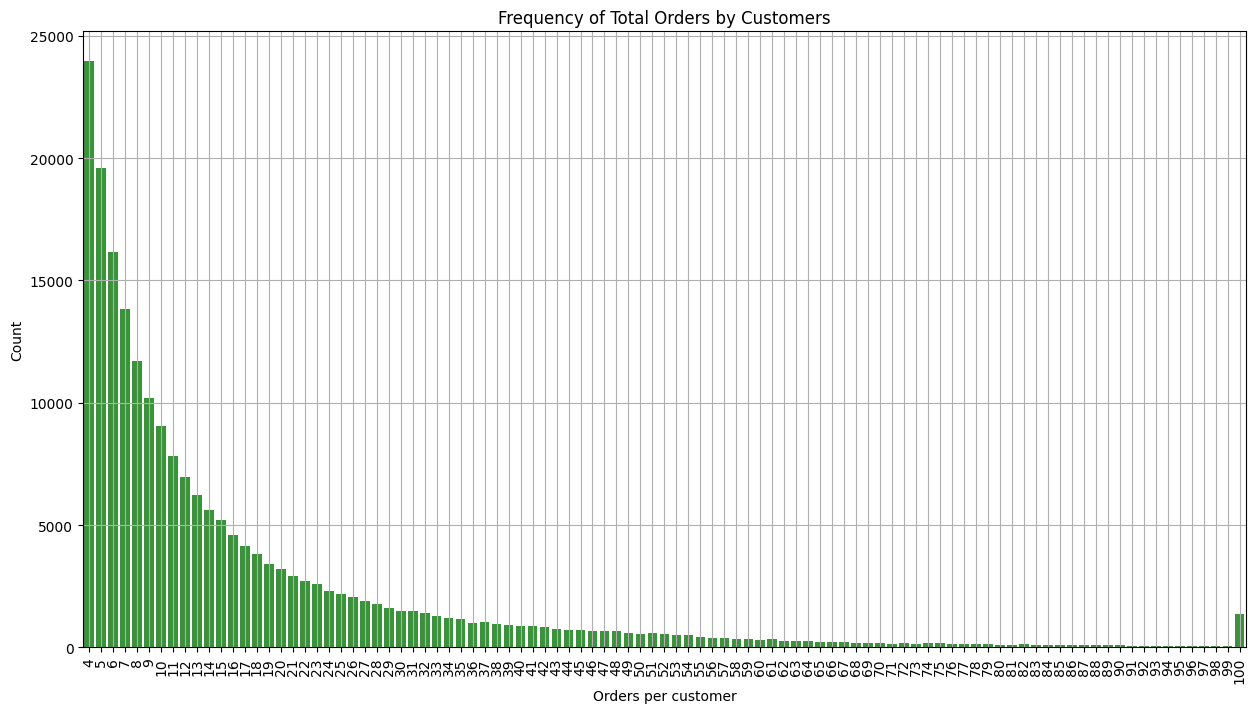

In [69]:
fig,ax =plt.subplots(figsize=(15,8))
ax = sns.barplot(x=order_number.index, y=order_number.values, color= color[2])
ax.set_xlabel('Orders per customer')
ax.set_ylabel('Count')
ax.xaxis.set_tick_params(rotation=90, labelsize=10)
ax.set_title('Frequency of Total Orders by Customers')
ax.grid(True)

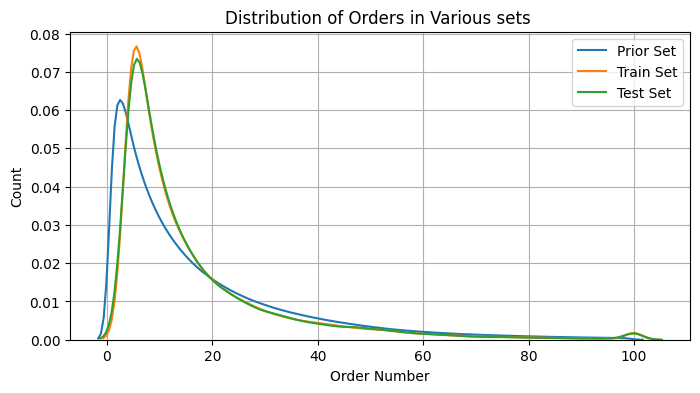

In [72]:
fig, ax = plt.subplots(figsize = (8,4))
ax = sns.kdeplot(orders.order_number[orders.eval_set == 'prior'], label = "Prior Set",lw=1.5)
ax = sns.kdeplot(orders.order_number[orders.eval_set == 'train'], label = "Train Set",lw=1.5)
ax = sns.kdeplot(orders.order_number[orders.eval_set == 'test'], label = "Test Set",lw=1.5)
ax.set_xlabel('Order Number')
ax.set_ylabel('Count')
ax.tick_params(axis='both', labelsize = 10)
ax.set_title('Distribution of Orders in Various sets ')
ax.grid(True)
ax.legend()


Text(0.5, 1.0, 'Total Orders per Day of Week')

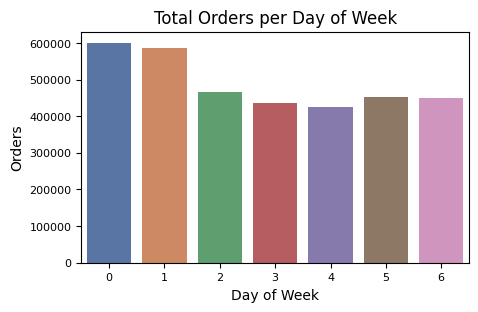

In [52]:
fig, ax = plt.subplots(figsize=(5,3))
ax = sns.countplot(x='order_dow',hue='order_dow', data=orders,palette='deep',legend=False)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Orders')
ax.tick_params(axis='both', labelsize=8)
ax.set_title('Total Orders per Day of Week')

Text(0.5, 1.0, 'Total Unique users per Day of Week')

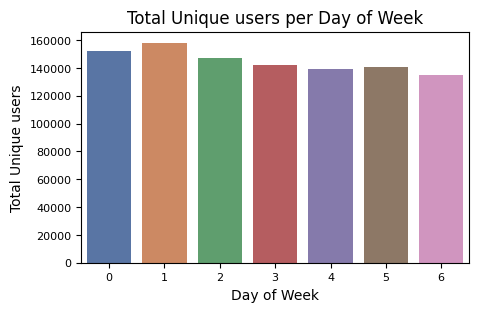

In [53]:
temp_df = orders.groupby('order_dow')['user_id'].nunique().reset_index(name='unique_users') # used reset_index as without it we are getting a series and we need a dataframe.

fig, ax = plt.subplots(figsize=(5,3))
ax = sns.barplot(x='order_dow', y='unique_users', hue='order_dow', data= temp_df, palette='deep', legend=False)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Unique users')
ax.tick_params(axis='both',labelsize=8)
ax.set_title('Total Unique users per Day of Week')

Text(0.5, 1.0, 'Total Orders per Hour of Day')

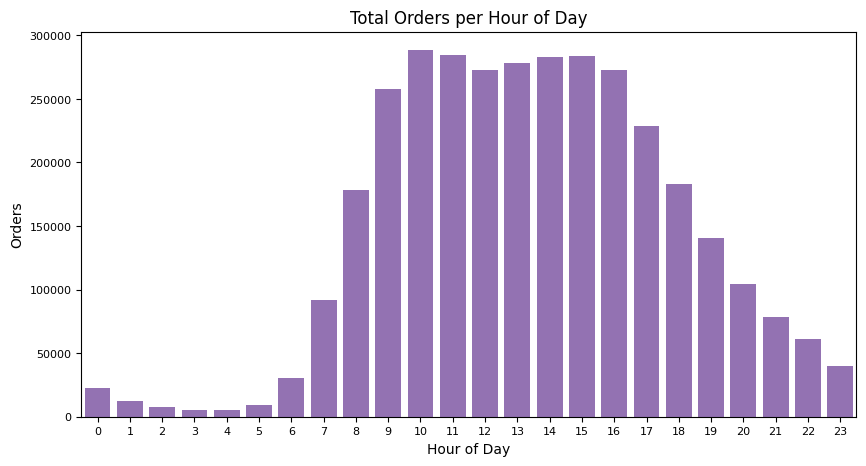

In [ ]:

fig,ax = plt.subplots(figsize = (10,5))
ax= sns.countplot(x='order_hour_of_day', data=orders, color=color[4])
ax.set_xlabel('Hour of Day',size=10)
ax.set_ylabel('Orders',size=10)
ax.tick_params(axis='both', labelsize=8)
ax.set_title('Total Orders per Hour of Day')

Text(0.5, 1.0, 'Orders VS Days since prior order')

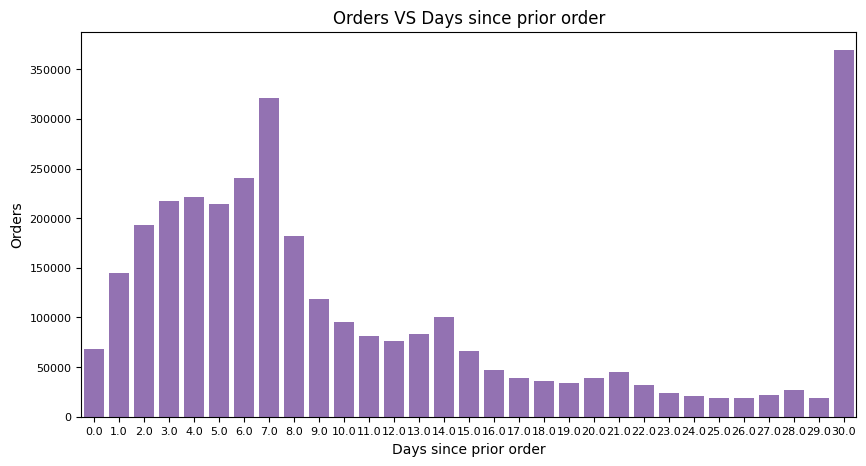

In [76]:
fig,ax = plt.subplots(figsize=(10,5))
ax = sns.countplot(x='days_since_prior_order',data=orders, color=color[4])
ax.set_xlabel('Days since prior order',size=10)
ax.set_ylabel('Orders', size=10)
ax.tick_params(axis='both',labelsize = 8)
ax.set_title('Orders VS Days since prior order')

Text(0.5, 1.0, 'Orders by day of week VS hour of day')

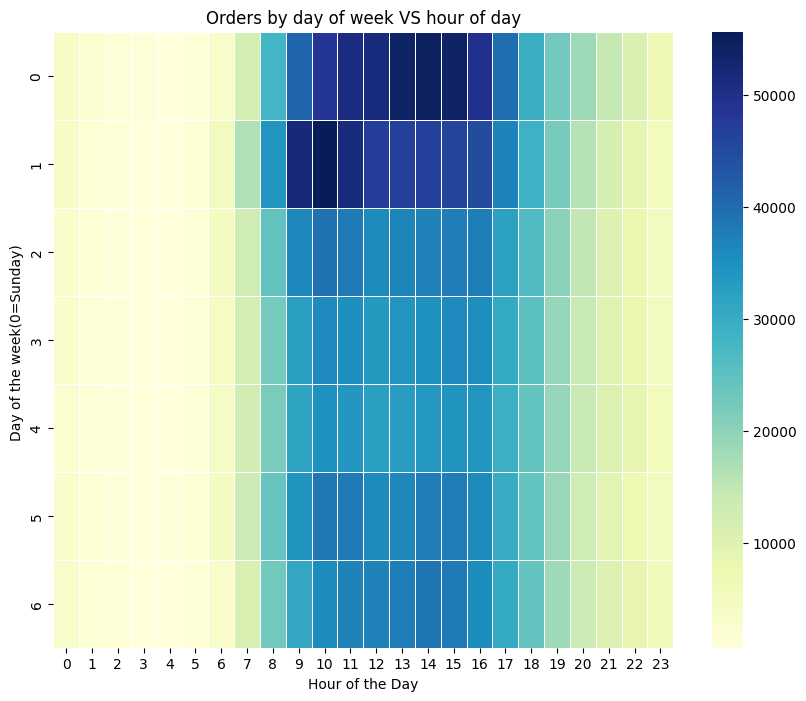

In [ ]:
heat_df = orders.groupby(['order_dow','order_hour_of_day'])['order_number'].size().unstack()

fig,ax = plt.subplots(figsize=(10,8))
sns.heatmap(heat_df,cmap="YlGnBu",linewidths=0.5)
ax.set_xlabel('Hour of the Day')
ax.set_ylabel('Day of the week(0=Sunday) ')
ax.set_title('Orders by day of week VS hour of day')